# Friends from proximity

Can you tell who someone's friends are just from which phones are near theirs?

## Setup

In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(0, "../src")

import pandas as pd
from mlxtend.frequent_patterns import association_rules, fpgrowth
import preprocess as pp
import friends as fr

## The data and baseline

The proximity data and student table are from the preprocessing notebook. We only use the students who appear in both Bluetooth and Facebook data, since a student without Facebook data is missing data, not necessarily a student without friends.

Two students picked randomly from this group are friends on Facebook with 2.11% probability. Every result obtained is compared against that baseline.

In [2]:
prox = pp.proximity()
st = pp.student_table()
fb = pp.clean_fb(pp.load_fb())

# students in a real pair and in the friendship file
# SELECT user FROM st WHERE in_bt AND in_fb
users = set(st.index[st.in_bt & st.in_fb])
friends = fr.friend_pairs(fb, users)
n = len(users)
# pairs of students that could be friends
possible = n * (n - 1) / 2
baseline = len(friends) / possible

print(f"{len(prox):,} proximity rows, {n} students, {len(friends):,} friendships, baseline {baseline:.2%}")

2,426,275 proximity rows, 657 students, 4,551 friendships, baseline 2.11%


## What counts as together

Before mining, we need to decide how storng the signal must be and which hours to use.

**Signal strength.** RSSI has no gap that separates "at the same table" from "in the same building" (see RSSI plot in `preprocess.ipynb`). We decide that two students are together when the signal is **-80** dBm or stronger, that keeps the strongest ~30% of readings. But we will also test -75 and -85 as well to see if there are better picks.

**Teaching hours.** One weekdays the number of rows increase drastically at 08:00, and falls of at 17:00. We call weekdays between 8-17 teaching hours, and the overwhelming majority of readings are withing theses hours.

In [3]:
rssi = -80
min_count = 100

In [4]:
print("RSSI 70% and 75% quantiles:", prox.rssi.quantile([0.7, 0.75]).to_list())
print(f"rows at {rssi} or stronger: {(prox.rssi >= rssi).mean():.0%}")

weekday = prox[~(prox.timestamp // pp.DAY % 7).isin([0, 6])]
# SELECT timestamp % DAY // 3600 AS hour, COUNT(*) FROM weekday GROUP BY hour ORDER BY hour
by_hour = ((weekday.timestamp % pp.DAY) // 3600).value_counts().sort_index()
print("weekday rows at hours 7, 8, 16, 17:", by_hour[[7, 8, 16, 17]].to_list())
print(f"rows in teaching hours: {fr.in_class(prox).mean():.0%}")

RSSI 70% and 75% quantiles: [-80.0, -79.0]
rows at -80 or stronger: 30%
weekday rows at hours 7, 8, 16, 17: [34625, 175029, 105225, 44947]
rows in teaching hours: 71%


In a lecture, the schedule puts students together, not their choice. Below we can see what happens when we exclude the teaching hours. From the pairs who are near at least once in class, 9.2% are facebook friends; but from the pairs who are near at least once outside of class, 15.1% are.

Therefore, time outside of class says more about friendship. Thus, we use those hours. But we also run on the teaching hours to compare.

In [5]:
near_share = {}
for teaching in [True, False]:
    p = fr.together(prox, rssi, teaching)
    near = {s for s in map(frozenset, zip(p.user_a, p.user_b)) if s.issubset(users)}
    near_share[teaching] = len(near.intersection(friends)) / len(near)
    print(f"teaching {teaching}: {len(p):,} rows, {len(near):,} pairs, {near_share[teaching]:.1%} friends")

teaching True: 503,022 rows, 24,600 pairs, 9.2% friends
teaching False: 228,469 rows, 10,927 pairs, 15.1% friends


## Transactions

Frequest itemset mining requires transactions, like items in ones shopping bag. For us, one transction is one student in one hour and the items are that student and everyone close to them in that hour. For example, if student 2 is near students 4 and 8 between 19:00-20:00, then the transaction is {2, 4, 8}.

The student is part of their own transaction, otherwise two students (2 and 4 from above) would give the the transactions {2} and {4}, so the pair would never appear in the same transaction as {2, 4}.

**1h window:** With a short time window, one group could be split into several smaller transcations. One hour has 12 scans (5-min scans) so a student only needs to be seen in one of them to be in the transaction. An hour is still short enough to keep two events of the same evening apart, e.g. dinner and party.

There's 50,874 transactions. Half only hold two students and 99% hold 16 or fewer, so the groups stay small when teaching hours are not included.

In [6]:
pairs = fr.together(prox, rssi)
X = fr.transactions(pairs)
sizes = X.sum(axis=1)

print(f"{len(X):,} transactions, {X.shape[1]} students")
print("students per transaction (50%, 75%, 99%):", sizes.quantile([0.5, 0.75, 0.99]).to_list(), "largest", sizes.max())

50,874 transactions, 664 students
students per transaction (50%, 75%, 99%): [2.0, 3.0, 16.0] largest 43


## Mining

We look for groups of students who appear together in at least 100 transactions. 
Due to the format of our data, a pair of students who spend one hour together appear in two transactions, one for each student.
This means that a threshold of at least 100 transactions means that we want to find students who have spent at least 50 hours together outside class during the four weeks.

We use frequent itemset mining, not clustering, 
because groups can overlap. 
A student can belong to multiple friend groups at the same time. 
The clustering methods in this course puts each student in at most one group.

In [7]:
%time fi = fr.mine(X, min_count)

CPU times: user 607 ms, sys: 0 ns, total: 607 ms
Wall time: 545 ms


In [8]:
%time fi_fp = fpgrowth(X, min_support=min_count / len(X), use_colnames=True)
print("same itemsets:", set(fi.itemsets) == set(fi_fp.itemsets))

CPU times: user 33.7 s, sys: 200 ms, total: 33.9 s
Wall time: 34.1 s
same itemsets: True


Apriori and FP-Growth find the same itemsets, as they should, but Apriori takes 0.3 seconds to run and FP-Growth takes ~36 seconds.

According to course theory, FP-Growth should be faster because it makes no candidates and reads the data only twice. 
One reason for this result is the library used: mlxtend runs Apriori with `numpy` on the whole table at once, 
but FP-Growth is written as Python loops. Our transactions are also short, so Apriori has few candidates to check.
The rest of the report uses Apriori for this reason.

In [9]:
size = fi.itemsets.apply(len)
groups = fr.maximal(fi)

# SELECT LEN(itemsets) AS size, COUNT(*) FROM fi GROUP BY size ORDER BY size
print(f"{len(fi)} frequent itemsets:", size.value_counts().sort_index().to_dict())
# SELECT LEN(itemsets) AS size, COUNT(*) FROM groups GROUP BY size ORDER BY size
print(f"{len(groups)} maximal groups:", groups.itemsets.apply(len).value_counts().sort_index().to_dict())
# SELECT *, LEN(itemsets) AS size FROM groups ORDER BY size DESC, support DESC LIMIT 5
groups.assign(size=groups.itemsets.apply(len)).sort_values(["size", "support"], ascending=False).head()

939 frequent itemsets: {1: 374, 2: 416, 3: 101, 4: 41, 5: 7}
380 maximal groups: {2: 306, 3: 48, 4: 19, 5: 7}


,support,itemsets,size
936,0.002398,"(324, 263, 176, 657, 52)",5
932,0.002202,"(324, 263, 176, 52, 221)",5
938,0.002202,"(324, 263, 657, 52, 221)",5
933,0.002103,"(263, 176, 657, 52, 221)",5
934,0.002084,"(324, 176, 657, 52, 221)",5


## Are the groups friends?

We say that a group which we find with our method is a good guess at a friend group if its members are Facebook friends more often than in a random group of students. Every pair inside a frequent group is itself a frequent pair, so testing the frequent pairs covers all groups.

In [10]:
result = fr.score(fi, friends, users)
result

pairs             396.000000
friend share        0.542929
times baseline     25.708436
friends found       0.047242
dtype: float64

Of the 396 pairs found, 54% are Facebook friends. That is 26 times the baseline of 2.11%. But the pairs cover only 4.7% of all friendships, so most friends are never found. This is fine in our case, since we only care about the friends that are in close proximity of each other. So people who are friends that are not spending time near each other are outside of our research question. 

In [11]:
# maximal groups where every member has facebook data
fb_groups = groups[groups.itemsets.apply(lambda s: s.issubset(users))]
group_size = fb_groups.itemsets.apply(len)
share = fb_groups.itemsets.apply(fr.group_share, friends=friends)
# SELECT group_size, COUNT(share), AVG(share) FROM fb_groups GROUP BY group_size ORDER BY group_size
by_size = share.groupby(group_size).agg(["count", "mean"])
big = fb_groups.itemsets[group_size >= 4]

print(f"groups where all pairs are friends: {(share == 1).mean():.0%}, where none are: {(share == 0).mean():.0%}")
print("amount of students in groups of 4 or 5:", len(set().union(*big)))
by_size


groups where all pairs are friends: 52%, where none are: 43%
amount of students in groups of 4 or 5: 9


,count,mean
itemsets,,
2,290,0.472414
3,46,0.746377
4,19,1.000000
5,7,1.000000


Larger groups are all Facebook friends more often. 47% are friends in the maximal pairs, 75% in the groups of three, and 100% in the groups of four and five. The last number depends on only nine students, so it describes one or two circles of friends, not a general rule.

The groups are mostly all or nothing: in 52% of groups, every pair is friends and in 43% no pair are friends. A group of students who spend many evenings together without being Facebook friends could live in the same housing, or friends who never added each other.


In [12]:
found = [s for s in fi.itemsets if len(s) == 2 and s.issubset(users)]
with_partner = set().union(*found)
with_friend = set().union(*[s for s in found if s in friends])
print(f"{len(with_partner)} of {n} students have a frequent partner, {len(with_friend)} of them a facebook friend")


216 of 657 students have a frequent partner, 177 of them a facebook friend


Perceived patterns: 216 of the 657 students have at least one frequent partner, and for 177 of them at least one of those partners is a Facebook friend. For the other two thirds of the students, the method names nobody.

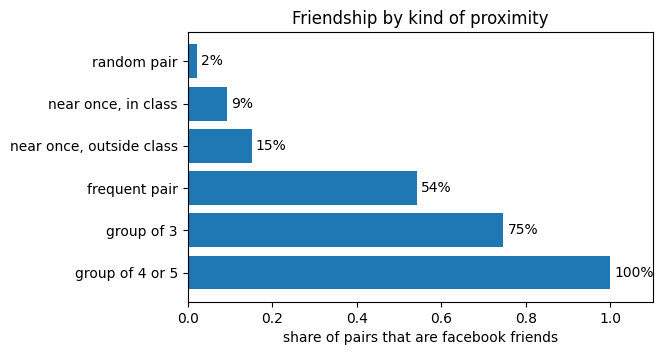

In [13]:
shares = pd.Series({
    "random pair": baseline,
    "near once, in class": near_share[True],
    "near once, outside class": near_share[False],
    "frequent pair": result["friend share"],
    "group of 3": by_size.loc[3, "mean"],
    "group of 4 or 5": share[group_size >= 4].mean(),
})
fig = fr.plot_shares(shares)


The figure puts the numbers side by side. "Near once" means near each other at least once during the four weeks. Being near once says little, especially in class. Being near often, outside class, says much more, and being part of a larger group that meets often says the most.


## Rules

A rule such as {530} → {249} reads: when student 530 is with someone outside class, 249 is there too. Its confidence is the share of 530's transactions that also contain 249. Confidence 1.0 means 249 was there every time.


In [14]:
rules = association_rules(fi, num_itemsets=len(X), metric="confidence", min_threshold=0.5)
print(f"{len(rules)} rules, lift {rules.lift.min():.0f} to {rules.lift.max():.0f}")
print(f"largest support of one student: {fi[size == 1].support.max():.2%}")
# SELECT antecedents, consequents, support, confidence, lift FROM rules ORDER BY confidence DESC LIMIT 5
rules[["antecedents", "consequents", "support", "confidence", "lift"]].sort_values("confidence", ascending=False).head()


654 rules, lift 15 to 241
largest support of one student: 3.25%


,antecedents,consequents,support,confidence,lift
100,(530),(249),0.010575,1.000000,53.721225
121,(321),(322),0.014467,0.998643,65.639498
57,(114),(376),0.006388,0.990854,150.473699
142,(419),(557),0.014074,0.988950,69.014892
45,(89),(341),0.006015,0.987097,145.137460


Every rule has a lift of 15 or more. Lift is the confidence divided by the support of the right side, and no student is in more than 3.25% of the transactions. A rule with confidence 0.5 therefore has a lift of at least 0.5 / 0.0325, about 15.

This also means the usual confidence trap does not happen here. The trap is a rule that has a high confidence only because the right side is in almost every transaction, with a lift near 1. Nobody in this data is with everyone, so no rule gets its confidence that way.

A larger lift does not mean a closer pair. When confidence is near 1, the lift is $\frac{1}{\text{support}_\text{right-side}}$, so lift mostly just shows how uncommon the right-side student is. {530} → {249} and {114} → {376} both have confidence near 1, but the first has a lift of 54 and the second a lift of 150; because 249 is in 1.9% of transactions and 376 in 0.66%.

Confidence add direction to the groups: 530 always has 249, but 249 may spend time with others too, thus {249} -> {530} has lower confidence than {530} -> {249}. Lift has no direction since it's the same regardless.


## How much do our choices matter

In [15]:
settings = [
    (-75, False, 100),
    (-80, False, 100),
    (-85, False, 100),
    (-80, True, 100),
    (-80, False, 50),
    (-80, False, 200),
    (-75, False, 200),
    (-75, True, 200),
]
rows = {}
for r, teaching, count in settings:
    f = fr.mine(fr.transactions(fr.together(prox, r, teaching)), count)
    rows[(r, teaching, count)] = fr.score(f, friends, users)
pd.DataFrame(rows).T.rename_axis(["rssi", "teaching", "min_count"]).round(3)

pairs  friend share  times baseline  friends found
rssi teaching min_count                                                     
-75  False    100         155.0         0.819          38.798          0.028
-80  False    100         396.0         0.543          25.708          0.047
-85  False    100        1077.0         0.298          14.113          0.071
-80  True     100        2831.0         0.345          16.325          0.214
     False    50         1384.0         0.340          16.115          0.103
              200         105.0         0.781          36.979          0.018
-75  False    200          60.0         0.800          37.881          0.011
     True     200         284.0         0.577          27.344          0.036

## How much do the choices matter?

Each row reruns everything with one or more choices changed.

- **Signal strength.** Looking at the top 3 rows we can see that loosening the threshold (-75 -> -80 -> -85) means that pairs that we find are less likely to be friends (82% -> 54% -> 30%), but at the same time we discover more friendships (2.8% -> 4.7% -> 7.1%).
- **Minimum support.** The same trade-off seems to be the case here as well: 34% friends at 50 transactions, 80% at 200.
- **Teaching hours.** Mining the teaching hours finds seven times as many pairs and 21% of all friendships, but only 34% of the pairs are friends, against 54% outside class (students are forced to "hang out" in class, regardless of being friends in real life).

One interesting discovery: setting the RSSI threshold to -75 AND min_count to 200 did not increase the percenatge of pairs that are friends. This means that requiring students to be closer and spend more time together might not always increase the odds of them being friends on Facebook, at least not based on this data.   

The conclusion does not really depend on the choices. In all rows, the pairs are 14x to 39x more likely to be friends than random pairs, and no "choice" finds more than a fifth of all friendships. The choices only move the balance between being right and finding many.

-85 together with teaching hours is left out, it takes too long to run.


## Answer

**Can you tell who someone's friends are just from which phones are near theirs?**

Partly. The students that someone spends many hours with outside class are often their friends: 54% of the pairs found are Facebook friends, 26 times more likely than picking two random students, and in groups of three or more most pairs are friends. So our results show that we are more correct than randomly saying that two students are friends.

The problem is that it discovers few of the friendships. The pairs found cover 4.7% of all friendships, and 2/3 of the students are not included in any pairs that we found. Most friends are not near each other often enough outside class to show up. Thus, proximity can only confirm some friendships.

Time in class gives us more pairs, since they spend more time in near proximity due to class, but more often than not we discover more non-friend pairs when we include school hours (percentage wise).

Relatively often, people add everyone they "know" (classmates) without actually being friends/spending time together. Therefore, one can say that the total amount of facebook friendships is inflated due to people befriending others on facebook who are in fact not their actual friends. Thus, we are essentially pointing out which students are actually real life friends, which is a more important metric than being friends on facebook; but in general we assume that real friends are also friends on facebook.

**Limitations.** The data covers one university, first-year students, four weeks, and the majority are men. The threshold, the window and the minimum support are our choices. The previous section shows that our choices change the balance, but not the answer.